In [16]:
import numpy as np
import pandas as pd

# Tabel 1: Target & PIC per cabang kota (tabel referensi, dibuat langsung sebagai DataFrame)
data_target_cabang = {
    "kota": ["Magelang", "Yogyakarta", "Semarang", "Solo", "Purworejo"],
    "target_bulanan": [45000000, 60000000, 55000000, 40000000, 30000000],
    "pic_cabang": ["Rani", "Joko", "Sari", "Bayu", "Fitri"],
}
'''
# Tabel 2: Data transaksi (disimpan sebagai CSV, lalu diunggah ke HDFS)
np.random.seed(55)
n = 500
kategori_list = ["Elektronik", "Fashion", "Makanan & Minuman", "Kesehatan & Kecantikan", "Rumah Tangga"]
kota_list = ["Magelang", "Yogyakarta", "Semarang", "Solo", "Purworejo"]
data_transaksi_t5 = {
    "order_id": [f"TRX-{i}" for i in range(n)],
    "kategori": np.random.choice(kategori_list, size=n),
    "kota": np.random.choice(kota_list, size=n),
    "unit_terjual": np.random.randint(1, 10, size=n),
    "harga_satuan": np.random.choice([25000, 50000, 75000, 100000, 150000], size=n),
}
pd.DataFrame(data_transaksi_t5).to_csv("transaksi_tugas5.csv", index=False)

!hdfs dfs -mkdir -p /user/mahasiswa/tugas5
!hdfs dfs -put -f transaksi_tugas5.csv /user/mahasiswa/tugas5/
print("Dataset siap. Tabel transaksi sudah diunggah ke HDFS: /user/mahasiswa/tugas5/transaksi_tugas5.csv")
print("Simpan juga 'data_target_cabang' di atas — kalian akan membuatnya menjadi DataFrame sendiri di notebook tugas.")
'''

'\n# Tabel 2: Data transaksi (disimpan sebagai CSV, lalu diunggah ke HDFS)\nnp.random.seed(55)\nn = 500\nkategori_list = ["Elektronik", "Fashion", "Makanan & Minuman", "Kesehatan & Kecantikan", "Rumah Tangga"]\nkota_list = ["Magelang", "Yogyakarta", "Semarang", "Solo", "Purworejo"]\ndata_transaksi_t5 = {\n    "order_id": [f"TRX-{i}" for i in range(n)],\n    "kategori": np.random.choice(kategori_list, size=n),\n    "kota": np.random.choice(kota_list, size=n),\n    "unit_terjual": np.random.randint(1, 10, size=n),\n    "harga_satuan": np.random.choice([25000, 50000, 75000, 100000, 150000], size=n),\n}\npd.DataFrame(data_transaksi_t5).to_csv("transaksi_tugas5.csv", index=False)\n\n!hdfs dfs -mkdir -p /user/mahasiswa/tugas5\n!hdfs dfs -put -f transaksi_tugas5.csv /user/mahasiswa/tugas5/\nprint("Dataset siap. Tabel transaksi sudah diunggah ke HDFS: /user/mahasiswa/tugas5/transaksi_tugas5.csv")\nprint("Simpan juga \'data_target_cabang\' di atas — kalian akan membuatnya menjadi DataFrame send

In [1]:
#SparkSession

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum as spark_sum, avg, count, rank, row_number, when
from pyspark.sql.window import Window

spark = SparkSession.builder \
    .appName("Tugas5-TugasMandiriJoinWindowSQL") \
    .master("local[*]") \
    .getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

print("SparkSession siap. Versi Spark:", spark.version)

26/09/19 19:46:39 WARN Utils: Your hostname, LOQ-CEED resolves to a loopback address: 127.0.1.1; using 192.168.0.120 instead (on interface wlan0)
26/09/19 19:46:39 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/19 19:46:39 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


SparkSession siap. Versi Spark: 3.5.9


In [8]:
#Membaca transaksi_tugas5.csv dari HDFS jadi df_transaksi
df_transaksi=spark.read.csv(
    "hdfs://localhost:9000/user/mahasiswa/tugas5/transaksi_tugas5.csv", 
    header=True, inferSchema=True
)
print("jumlah baris dataframe dari HDFS : ",df_transaksi.count())
df_transaksi.show(10)
df_transaksi.printSchema()


jumlah baris dataframe dari HDFS :  500
+--------+--------------------+----------+------------+------------+
|order_id|            kategori|      kota|unit_terjual|harga_satuan|
+--------+--------------------+----------+------------+------------+
|   TRX-0|   Makanan & Minuman| Purworejo|           8|       75000|
|   TRX-1|          Elektronik|      Solo|           9|       75000|
|   TRX-2|Kesehatan & Kecan...|      Solo|           6|      100000|
|   TRX-3|             Fashion|Yogyakarta|           6|      100000|
|   TRX-4|          Elektronik|Yogyakarta|           2|       75000|
|   TRX-5|Kesehatan & Kecan...|  Magelang|           4|      100000|
|   TRX-6|        Rumah Tangga|  Magelang|           6|       25000|
|   TRX-7|          Elektronik|  Semarang|           8|       50000|
|   TRX-8|             Fashion|  Semarang|           5|       25000|
|   TRX-9|          Elektronik|Yogyakarta|           3|      100000|
+--------+--------------------+----------+------------+--------

In [13]:
#menambahkan kolom pendapatan (unit terjual x harga satuan)
df_transaksi=df_transaksi.withColumn("pendapatan",col("unit_terjual")*col("harga_satuan"))
df_transaksi.show(10)

+--------+--------------------+----------+------------+------------+----------+
|order_id|            kategori|      kota|unit_terjual|harga_satuan|pendapatan|
+--------+--------------------+----------+------------+------------+----------+
|   TRX-0|   Makanan & Minuman| Purworejo|           8|       75000|    600000|
|   TRX-1|          Elektronik|      Solo|           9|       75000|    675000|
|   TRX-2|Kesehatan & Kecan...|      Solo|           6|      100000|    600000|
|   TRX-3|             Fashion|Yogyakarta|           6|      100000|    600000|
|   TRX-4|          Elektronik|Yogyakarta|           2|       75000|    150000|
|   TRX-5|Kesehatan & Kecan...|  Magelang|           4|      100000|    400000|
|   TRX-6|        Rumah Tangga|  Magelang|           6|       25000|    150000|
|   TRX-7|          Elektronik|  Semarang|           8|       50000|    400000|
|   TRX-8|             Fashion|  Semarang|           5|       25000|    125000|
|   TRX-9|          Elektronik|Yogyakart

In [17]:
#buat df_target dari data target cabang
df_target = spark.createDataFrame(pd.DataFrame(data_target_cabang))
df_target.show(10)
                                  

+----------+--------------+----------+
|      kota|target_bulanan|pic_cabang|
+----------+--------------+----------+
|  Magelang|      45000000|      Rani|
|Yogyakarta|      60000000|      Joko|
|  Semarang|      55000000|      Sari|
|      Solo|      40000000|      Bayu|
| Purworejo|      30000000|     Fitri|
+----------+--------------+----------+



In [82]:
## A. Join dan Perbandingan Target 
#total pendapatan per kota
ringkasan = df_transaksi.groupBy("kota").agg(
    spark_sum("pendapatan").alias("total_pendapatan")    
)

#join dengan df target
from pyspark.sql.functions import round
df_gabung=ringkasan.join(df_target, on="kota", how="inner")
df_gabung = df_gabung.withColumn("pencapaian_persen",
                                 col("total_pendapatan")/col("target_bulanan")*100
                                ).orderBy(col("pencapaian_persen").desc())

#df_gabung.orderBy("pencapaian_persen", ascending=False).show()
df_gabung.show(10)


+----------+----------------+--------------+----------+------------------+
|      kota|total_pendapatan|target_bulanan|pic_cabang| pencapaian_persen|
+----------+----------------+--------------+----------+------------------+
| Purworejo|        45650000|      30000000|     Fitri|152.16666666666669|
|      Solo|        33475000|      40000000|      Bayu|           83.6875|
|Yogyakarta|        47275000|      60000000|      Joko| 78.79166666666667|
|  Magelang|        31650000|      45000000|      Rani| 70.33333333333334|
|  Semarang|        38175000|      55000000|      Sari|  69.4090909090909|
+----------+----------------+--------------+----------+------------------+



In [85]:
##B. Window Function
#Mencari top 1 kategori tiap kota
window_spec=Window.partitionBy("kategori").orderBy(col("pendapatan").desc())

#Tambah kolom peringkat
df_ranked=df_transaksi.withColumn("rank_kategori", row_number().over(window_spec))

#Filter hasilnya (munculkan peringkat 1 tiap kategori)
df_ranked.filter(col("rank_kategori")==1)\
    .orderBy("", "rank_kategori")\
    .show()

+--------+--------------------+----------+------------+------------+----------+-------------+
|order_id|            kategori|      kota|unit_terjual|harga_satuan|pendapatan|rank_kategori|
+--------+--------------------+----------+------------+------------+----------+-------------+
|  TRX-35|          Elektronik| Purworejo|           9|      150000|   1350000|            1|
|  TRX-92|             Fashion|      Solo|           9|      150000|   1350000|            1|
| TRX-157|Kesehatan & Kecan...|Yogyakarta|           9|      150000|   1350000|            1|
|  TRX-81|   Makanan & Minuman|  Semarang|           9|      150000|   1350000|            1|
| TRX-350|        Rumah Tangga|Yogyakarta|           9|      150000|   1350000|            1|
+--------+--------------------+----------+------------+------------+----------+-------------+



In [88]:
print("ini dataframe transaksi")
df_transaksi.show(10)
print("ini dataframe target")
df_target.show()

ini dataframe transaksi
+--------+--------------------+----------+------------+------------+----------+
|order_id|            kategori|      kota|unit_terjual|harga_satuan|pendapatan|
+--------+--------------------+----------+------------+------------+----------+
|   TRX-0|   Makanan & Minuman| Purworejo|           8|       75000|    600000|
|   TRX-1|          Elektronik|      Solo|           9|       75000|    675000|
|   TRX-2|Kesehatan & Kecan...|      Solo|           6|      100000|    600000|
|   TRX-3|             Fashion|Yogyakarta|           6|      100000|    600000|
|   TRX-4|          Elektronik|Yogyakarta|           2|       75000|    150000|
|   TRX-5|Kesehatan & Kecan...|  Magelang|           4|      100000|    400000|
|   TRX-6|        Rumah Tangga|  Magelang|           6|       25000|    150000|
|   TRX-7|          Elektronik|  Semarang|           8|       50000|    400000|
|   TRX-8|             Fashion|  Semarang|           5|       25000|    125000|
|   TRX-9|      

In [57]:
##C. Spark SQL
#Mendaftarkan df_transaksi dan df_target sebagai tabel sementara
df_transaksi.createOrReplaceTempView("transaksi")
df_target.createOrReplaceTempView("target")

print("kedua tabel transaksi dan target berhasil didaftarkan sebagai tabel sementara")
#Menampilkan kota, pic_cabang, jumlah transaksi dan diurutkan dari jumlah terbanyak
hasil_sql= spark.sql('''
select t.kota, g.pic_cabang, count(t.kota) as jumlah_transaksi
from transaksi t
join target g on t.kota=g.kota
group by t.kota, g.pic_cabang
order by jumlah_transaksi desc
''')
hasil_sql.show(10)

kedua tabel transaksi dan target berhasil didaftarkan sebagai tabel sementara
+----------+----------+----------------+
|      kota|pic_cabang|jumlah_transaksi|
+----------+----------+----------------+
| Purworejo|     Fitri|             116|
|Yogyakarta|      Joko|             110|
|      Solo|      Bayu|              95|
|  Semarang|      Sari|              93|
|  Magelang|      Rani|              86|
+----------+----------+----------------+



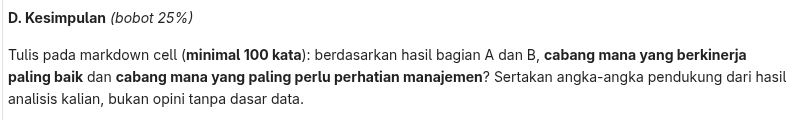

Menurut saya, setelah dilakukannya pemrosesan pada dataframe transaksi dengan target, dapat diambil kesimpulan bahwa berdasarkan hasil bagian Acabang dengan kinerja paling baik ialah cabang kota purworejo. Dimana selain mencapai target, cabang tersebut bahkan melampaui target, yang dimana 152,16 persen pencapaian, yang didapat dari total pendapatan dibanding target bulanannya, atau 1,5 kali lipat lebih tinggi daripada target. Sementara untuk cabang yang perlu diperhatikan manajemennya ialah cabang kota semarang, dimana di kota tersebut, pencapaiannya berada di 69 persen.

Alasan yang bisa dijadikan dugaan mengapa hal tersebut terjadi ialah, di kota purworejo, berdasarkan hasil bagian B, kategori elektronik merupakan barang yang penjualannya berada di peringkat pertama, mungkin cabang purworejo menggencarkan penjualan barang dengan kategori elektronik sehingga bisa mencapai bahkan melampaui target bulanan. Sementara di kota semarang, kategori penjualan paling tingginya ialah makananan dan minuman. Bisa saya sarankan untuk kota semarang lebih dikembangkan lagi penjualan di kategori tersebut dan tidak terlalu merambat ke kategori lain sehingga target penjualan bulanan bisa tercapai sesuai target.

In [89]:
#Menghentikan spark session (bcos why not ?)
spark.stop()
print("Sesi spark pada tugas saat ini, sampai sini saja")

Sesi spark pada tugas saat ini, sampai sini saja
